# Decay

Radioactive decay of a nucleus is $N(t)=N_0 e^{-t/\tau}$ where $N_0$ is the number of the nucleus in question initially and $\tau$ is the half life of the nucleus.  $N(t)$ is the number of nuclei remaining at time $t$.

A program that draws random numbers according to what we would expect to measure for $N(t)$  given $\tau$. 

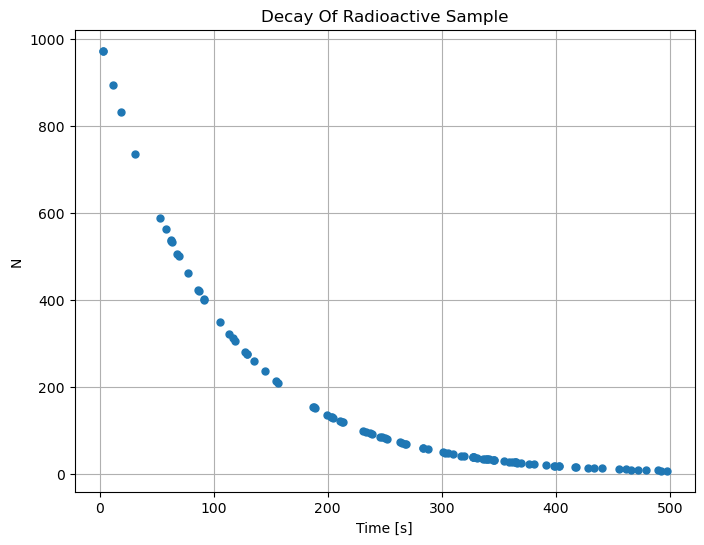

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters
N0 = 1000  # Initial number of nuclei
tau = 100  # Half-life in seconds
t_max = 500  # Maximum time in seconds

t = np.random.uniform(0, t_max, 100)

N = N0 * np.exp(-t / tau)

plt.figure(figsize=(8, 6))
plt.plot(t, N, 'o', markersize=5)
plt.xlabel('Time [s]')
plt.ylabel('N')
plt.title('Decay Of Radioactive Sample')
plt.grid()
plt.show()


Fitted N0: 1001.6471913215753 ± 10.174218812473928
Fitted tau: 99.36967874674598 ± 0.7838956728348375
Corr. between N0 and tau: -0.7404863784626478


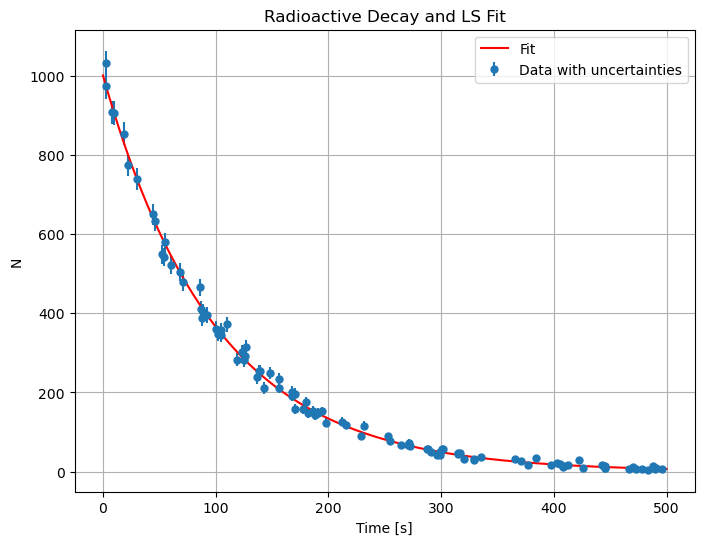

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

N0 = 1000  
tau = 100  
t_max = 500  

np.random.seed(100)  
t = np.random.uniform(0, t_max, 100)

# Calculate the number of nuclei remaining at each time
N = N0 * np.exp(-t / tau)

# Adding poission noise to the data:
N_observed = np.random.poisson(N)

# The simplistic model: 
def decay_model(t, N0, tau):
    return N0 * np.exp(-t / tau)

#LS Fit: curve_fit from scipy.optimize works fine, however, might as well use another function

popt, pcov = curve_fit(decay_model, t, N_observed, p0=[N0, tau], sigma=np.sqrt(N_observed), absolute_sigma=True)

# Extracting the params out of the fit for analysis
N0_fit, tau_fit = popt
N0_err, tau_err = np.sqrt(np.diag(pcov))

print(f"Fitted N0: {N0_fit} ± {N0_err}")
print(f"Fitted tau: {tau_fit} ± {tau_err}") 

correlation = pcov[0, 1] / (N0_err * tau_err)
print(f"Corr. between N0 and tau: {correlation}")






# PLOT
plt.figure(figsize=(8, 6))

# Plot the observed data with error bars
plt.errorbar(t, N_observed, yerr=np.sqrt(N_observed), fmt='o', markersize=5, label='Data with uncertainties')

# Plot the fitted curve
t_fit = np.linspace(0, t_max, 500)  # Smooth curve for the fit
N_fit = decay_model(t_fit, N0_fit, tau_fit)
plt.plot(t_fit, N_fit, 'r-', label='Fit')

plt.xlabel('Time [s]')
plt.ylabel('N')
plt.title('Radioactive Decay and LS Fit')
plt.legend()
plt.grid()
plt.show()

<Figure size 640x480 with 0 Axes>

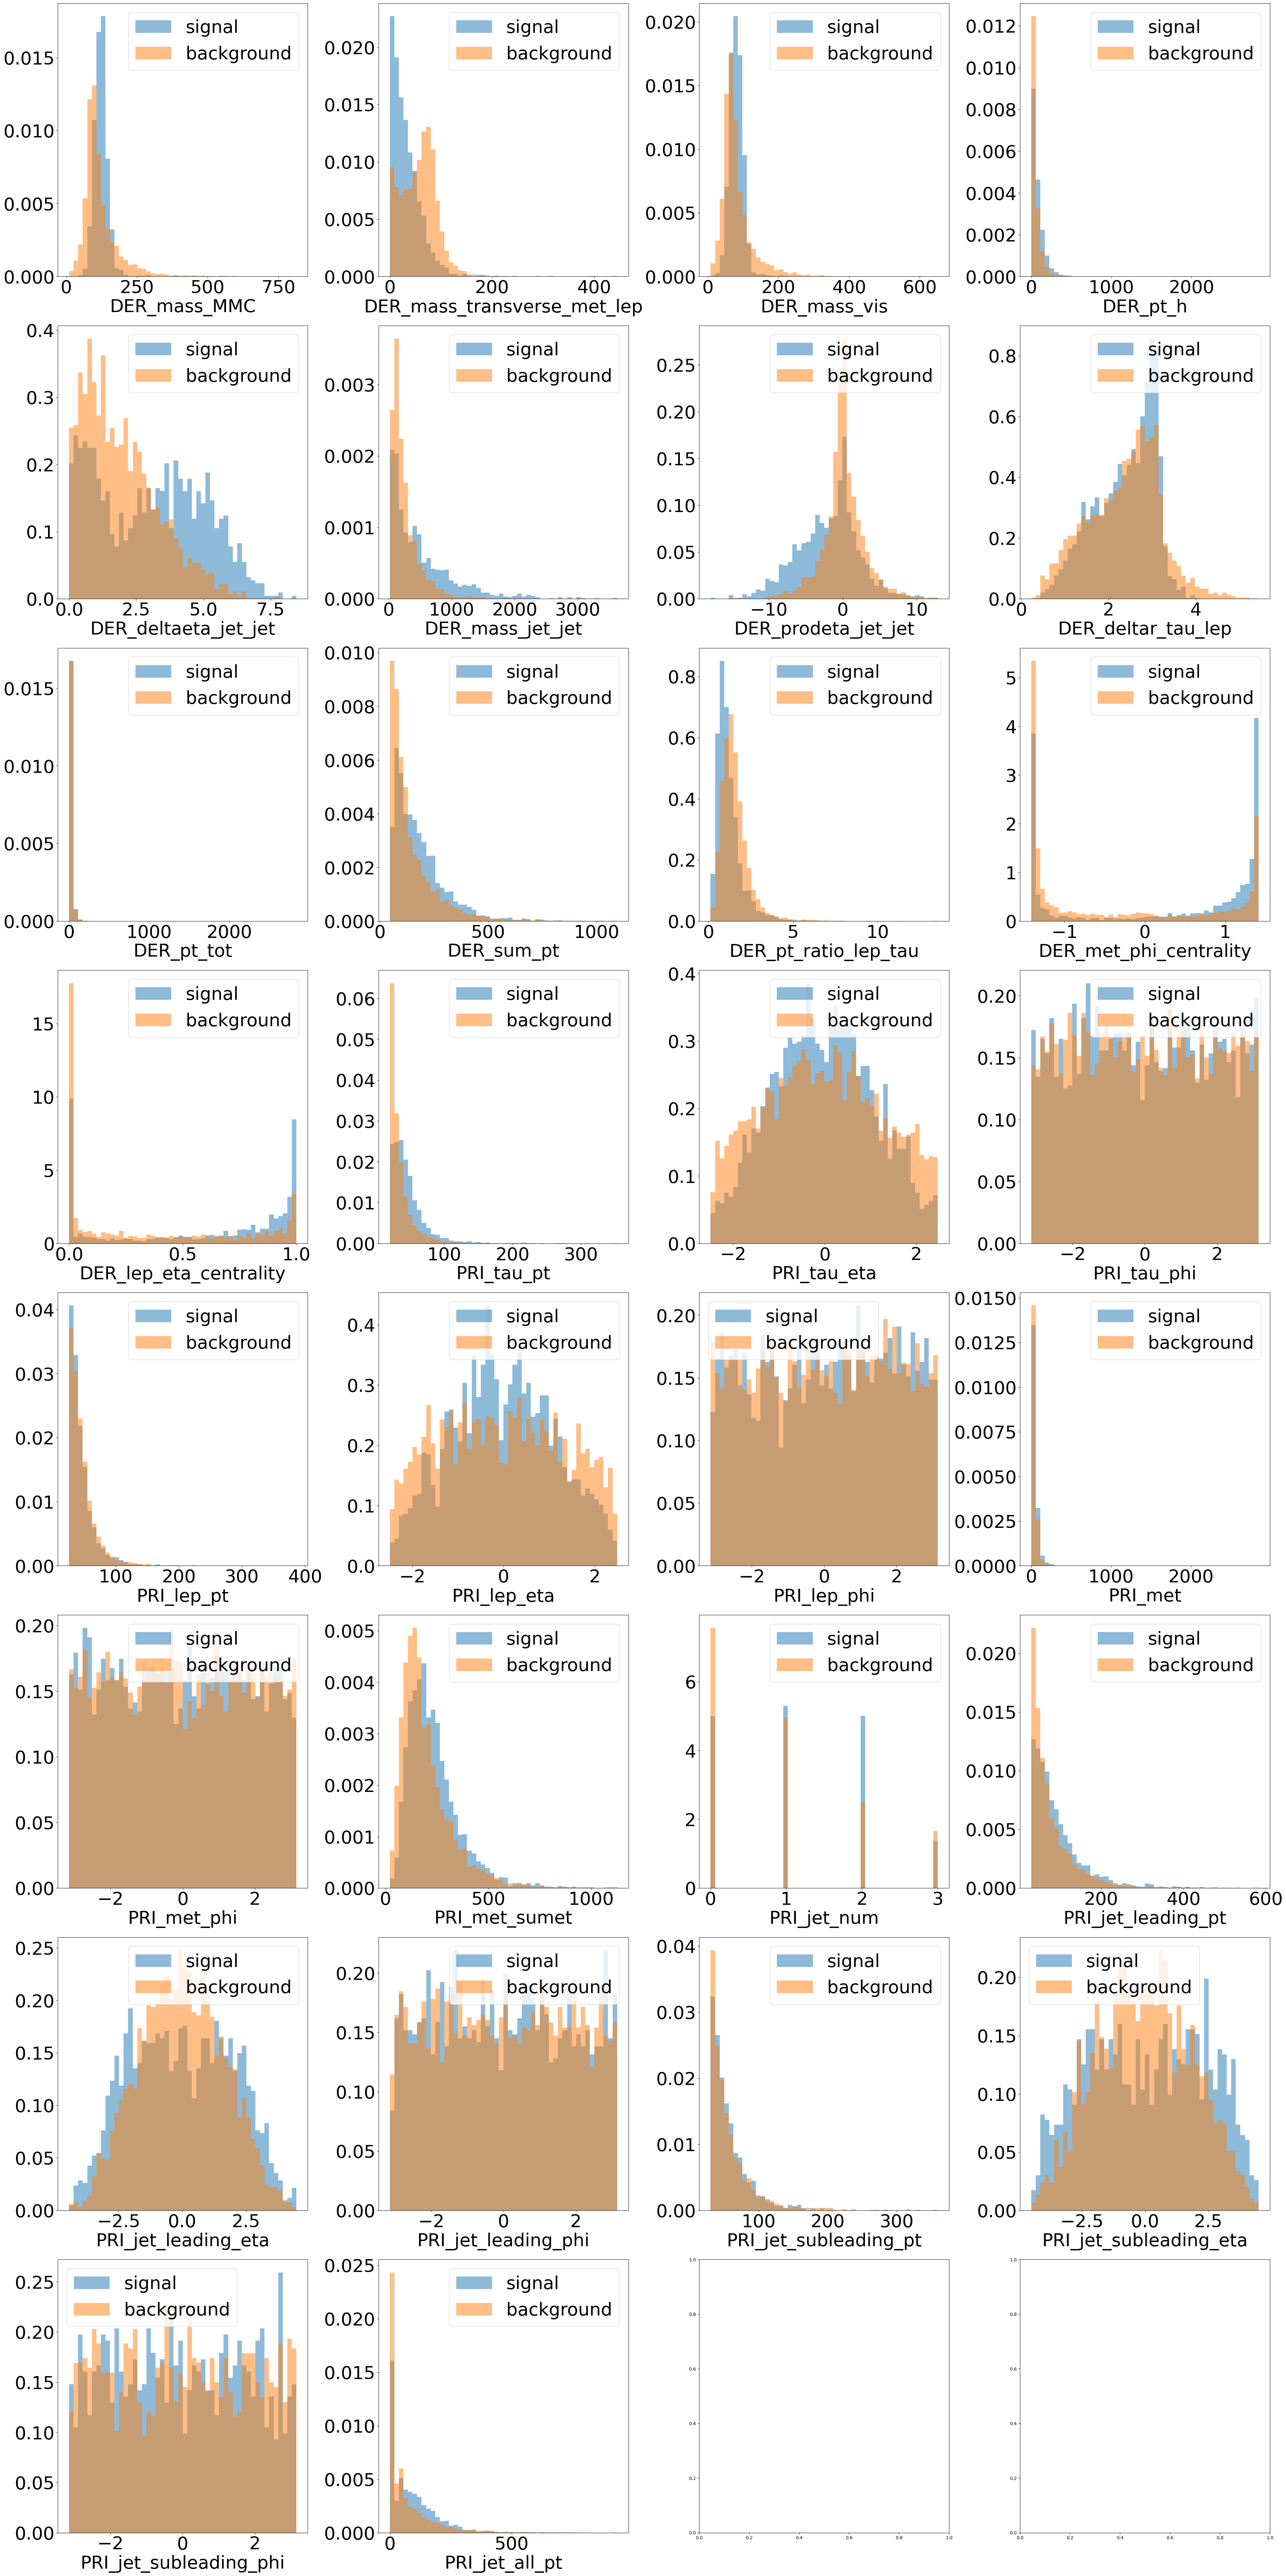

In [32]:
plt.figure()


fig, axs = plt.subplots(8, 4, figsize=(40, 80))

for ix, ax in enumerate(axs.reshape(-1)):
    col = data.columns[ix + 1]
    if col == "Weight" or col == "Label":
        continue
    signal = data[col][data.Label == "s"].to_numpy()
    mask_signal = signal > -999
    background = data[col][data.Label == "b"].to_numpy()
    mask_background = background > -999
    xmin = min(np.min(background[mask_background]), np.min(signal[mask_signal]))
    xmax = max(np.max(background[mask_background]), np.max(signal[mask_signal]))

    ax.hist(signal[mask_signal], bins=np.linspace(xmin, xmax, 51), alpha=0.5, label="signal", density=True)
    ax.hist(background[mask_background], bins=np.linspace(xmin, xmax, 51), alpha=0.5, label="background", density=True)

    ax.set_xlabel(col, fontsize=40)
    ax.set_xlabel(col, fontsize=40)
    ax.tick_params(axis="both", which="major", labelsize=40)
    ax.legend(fontsize=40)
plt.tight_layout()
plt.show()